# Lecture 8 — Class Exercise- Dennis Sebastian
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json
import requests

## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from

In [2]:
df = pd.read_csv("C:/Users/denni/Downloads/gapminder (1).csv")

In [3]:
df.head()

,Country,Continent,GDP_per_capita,Life_expectancy,Population,CO2_per_capita
0,Afghanistan,Asia,550,63,38000000,0.3
1,Australia,Oceania,54000,83,26000000,15.1
2,Bangladesh,Asia,2200,73,170000000,0.5
3,Brazil,Americas,8900,76,215000000,2.1
4,Canada,Americas,46000,82,38000000,14.2


In [4]:
df.tail()

,Country,Continent,GDP_per_capita,Life_expectancy,Population,CO2_per_capita
42,UK,Europe,46000,81,68000000,5.1
43,USA,Americas,62000,79,335000000,14.2
44,Venezuela,Americas,7000,72,29000000,4.0
45,Vietnam,Asia,3500,76,97000000,3.2
46,Zimbabwe,Africa,1100,62,16000000,0.6


In [5]:
df.columns


Index(['Country', 'Continent', 'GDP_per_capita', 'Life_expectancy',
       'Population', 'CO2_per_capita'],
      dtype='object')

In [6]:
df = df.rename(columns={
    "Country": "country",
    "Continent": "continent",
    "GDP_per_capita": "gdpPercap",
    "Life_expectancy": "lifeExp",
    "Population": "pop",
    "CO2_per_capita": "co2"
})

In [7]:

global_avg = df["lifeExp"].mean()
df["lifeExp_dev"] = df["lifeExp"] - global_avg

C:\Users\denni\AppData\Local\Temp\ipykernel_12976\1002424193.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


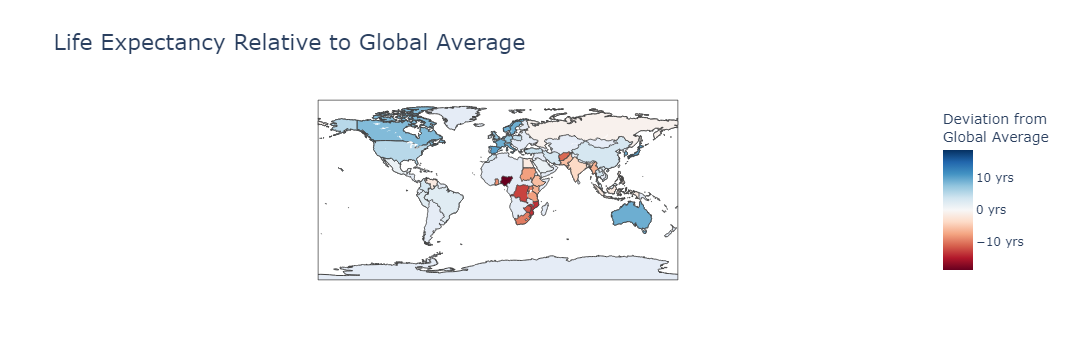

In [8]:
fig = px.choropleth(
    df,
    locations="country",
    locationmode="country names",
    color="lifeExp_dev",
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0,
    hover_name="country",
    hover_data={
        "lifeExp": True,
        "lifeExp_dev": True,
        "country": False
    },
    title="Life Expectancy Relative to Global Average"
)

fig.update_layout(
    title_font=dict(size=22),
    coloraxis_colorbar=dict(
        title="Deviation from<br>Global Average",
        ticksuffix=" yrs"
    )
)

fig.show()

In [9]:
lowest = df.sort_values("lifeExp_dev").iloc[0]

print(
    f"Insight: {lowest['country']} has the lowest life expectancy "
    f"relative to the global average ({lowest['lifeExp_dev']:.1f} years below)."
)

Insight: Nigeria has the lowest life expectancy relative to the global average (-18.7 years below).


## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`

{'scalerank': 2, 'adm1_code': 'USA-3514', 'diss_me': 3514, 'adm1_cod_1': 'USA-3514', 'iso_3166_2': 'US-MN', 'wikipedia': 'http://en.wikipedia.org/wiki/Minnesota', 'sr_sov_a3': 'US1', 'sr_adm0_a3': 'USA', 'iso_a2': 'US', 'adm0_sr': 1, 'admin0_lab': 2, 'name': 'Minnesota', 'name_alt': 'MN|Minn.', 'name_local': None, 'type': 'State', 'type_en': 'State', 'code_local': 'US32', 'code_hasc': 'US.MN', 'note': None, 'hasc_maybe': None, 'region': 'Midwest', 'region_cod': None, 'region_big': 'West North Central', 'big_code': None, 'provnum_ne': 0, 'gadm_level': 1, 'check_me': 10, 'scaleran_1': 2, 'datarank': 1, 'abbrev': 'Minn.', 'postal': 'MN', 'area_sqkm': 0, 'sameascity': -99, 'labelrank': 0, 'featurec_1': 'Admin-1 scale rank', 'admin': 'United States of America', 'name_len': 9, 'mapcolor9': 1, 'mapcolor13': 1, 'featureclass': 'Admin-1 scale rank'}


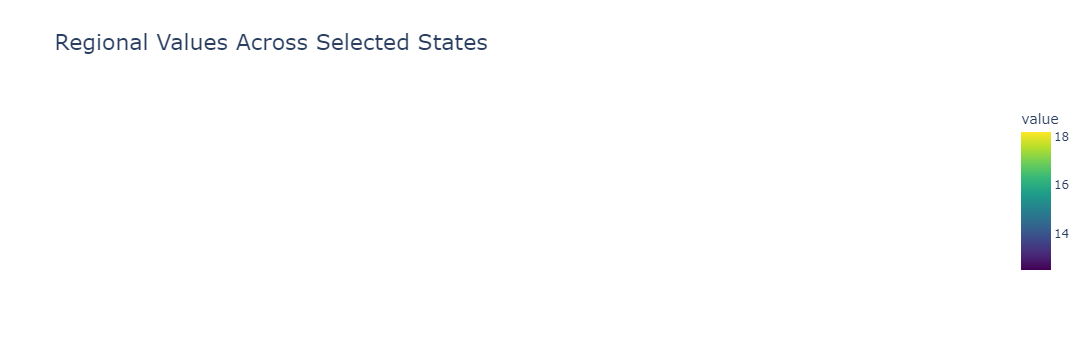

Insight: Bayern has the lowest value (12.5).


In [10]:

# 1. Load your dataset
# ---------------------------------------------------------
df = pd.DataFrame({
    "region": ["Bayern", "Berlin", "Hamburg", "Hessen"],
    "value": [12.5, 18.2, 15.1, 14.3]
})

# ---------------------------------------------------------
# 2. Load GeoJSON from URL
# ---------------------------------------------------------
url = "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_1_states_provinces_shp.geojson"
geo = requests.get(url).json()

# Inspect properties to find the correct key
print(geo["features"][0]["properties"])

# ---------------------------------------------------------
# 3. Build the choropleth
# ---------------------------------------------------------
fig = px.choropleth(
    df,
    geojson=geo,
    locations="region",
    featureidkey="properties.name",
    color="value",
    color_continuous_scale="Viridis",
    hover_name="region",
    hover_data={"value": True},
    title="Regional Values Across Selected States"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(title_font=dict(size=22))

fig.show()

# ---------------------------------------------------------
# 4. Insight
# ---------------------------------------------------------
lowest = df.sort_values("value").iloc[0]
print(f"Insight: {lowest['region']} has the lowest value ({lowest['value']}).")


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*